In [ ]:

# Import para visualizar as pastas
import os
import sys

# Adiciona a pasta raiz do projeto ao path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from pathlib import Path

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bilbiotecas src/
from src.load_data import load_raw_data

## Etapa 1 - Carregar e entender o dataset

In [132]:
# 2 - Carreganddo o dataset
df = load_raw_data()

Arquivo já existe, pulando donwload.
Arquivo salvo no projeto /mnt/SegundoHD/Documentos/Projetos/ChatbotCredito em: /mnt/SegundoHD/Documentos/Projetos/ChatbotCredito/data/raw


In [133]:
# 3- Visualizando os dados do dataframe
display(df.head(10))

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


Detalhes das features e target

---

| Variável                      | Descrição                             | Tipo                          |
| ----------------------------- | ------------------------------------- | ----------------------------- |
| person_age                    | Idade                                 | Numérico Discreto - Int       |
| person_income                 | Renda anual                           | Numérico Discreto - Int       |
| person_home_ownership         | Situação da moradia                   | Categórico Nominal - String   |
| person_emp_length             | Tempo de emprego (em anos)            | Numérico Contínuo - Float     |
| loan_intent                   | Intenção de empréstimo                | Categórico Nominal - String   |
| loan_grade                    | Grau do empréstimo                    | Categórico Ordinal - String   |
| loan_amnt                     | Valor do empréstimo                   | Numérico Discreto - Int       |
| loan_int_rate                 | Taxa de juro                          | Numérico Contínuo - Float     |
| loan_status                   | Situação do empréstimo                | Categórico Ordinal - Int      |
| loan_percent_income           | Renda percentual                      | Numérico Contínuo - Float     |
| cb_person_default_on_file     | Inadimplência histórica               | Categórico Ordinal - String   |
| cb_person_cred_hist_length    | Comprimento do histórico de crédito   | Numérico Discreto - Int       |

**Target - loan_status (0 significa não inadimplente, 1 significa inadimplente)**

In [134]:
# 4 - Estrutua do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [135]:
# 5 - Estatísticas básicas
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [136]:
# 6 - Listar Colunas
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

## Etapa 2 - Analisar valores nulos

In [137]:
# 1 - Quantidade de Nulos
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [138]:
# 2 - Percentual de nulos
(df.isna().sum() / len(df)) * 100

'''
Pega os valores nulos das colunas que contém e tira a porcentagem deles.
Verirfica se são poucos ou muitos valores nulos naquela coluna.
✔️ Até ~5%
👉 baixo → fácil de tratar
✔️ Entre 5% e 15%
👉 moderado → precisa pensar melhor
❌ >30%
👉 problemático
'''


'\nPega os valores nulos das colunas que contém e tira a porcentagem deles.\nVerirfica se são poucos ou muitos valores nulos naquela coluna.\n✔️ Até ~5%\n👉 baixo → fácil de tratar\n✔️ Entre 5% e 15%\n👉 moderado → precisa pensar melhor\n❌ >30%\n👉 problemático\n'

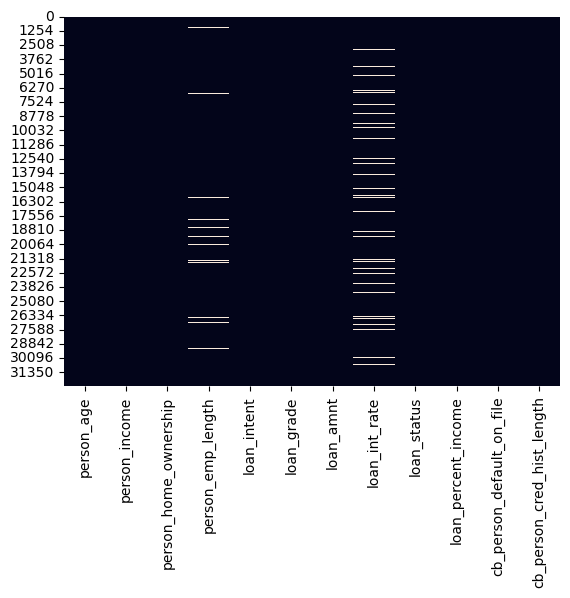

In [139]:
sns.heatmap(df.isna(), cbar=False)
plt.show()

## Etapa 3 - Decidir estratégia

`person_emp_length` -> 2.7% de valores nulos.
- Pode ser desempregado ou dado não informado.
- Opções:
  - Mediana (melhor opção)
  - Criar flag

`loan_int_rate` -> 9.5% de valores nulos.
- Pode ser erro de coleta ou casos específicos.
- Opção:
  - Mediana (mais robusta que a média)

Resumo:
- person_emp_length → mediana
- loan_int_rate → mediana


## Etapa 4 - Entender a variável alvo vs nulos

In [140]:
df.groupby(df['loan_int_rate'].isna())['loan_status'].mean()

loan_int_rate
False    0.219379
True     0.206675
Name: loan_status, dtype: float64

Resultado:

- Não nulo → 0.219
- Nulo → 0.206

Praticamente Irrelevante. Os valores nulos de `loan_int_rate` NÃO têm impacto significativo no target (`loan_status`).

Preencher com a mediana os valores nulos.

#### Tratando os nulos

In [141]:
# Subistituindo valores nulos pela mediana
#df['person_emp_length'].fillna(df['person_emp_length'].mean(), inplace=True)
df.fillna({'person_emp_length': df['person_emp_length'].mean()}, inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].mean())
df.fillna({'loan_int_rate': df['loan_int_rate'].mean()}, inplace=True)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [142]:
# Verificando se foi feita a substituição
df.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

### Etapa 4.1 - OUTLIERS

Problemas detectados:

- `person_age` -> até 144
- `person_emp_length` -> até 123

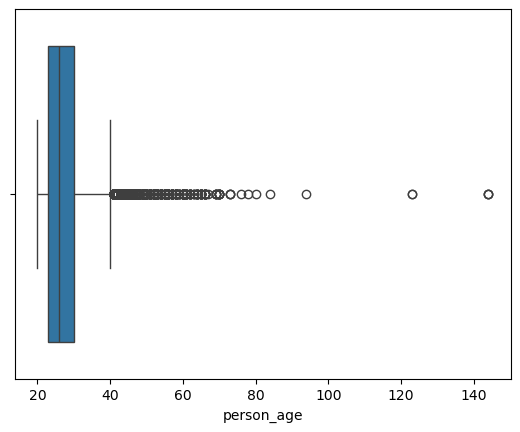

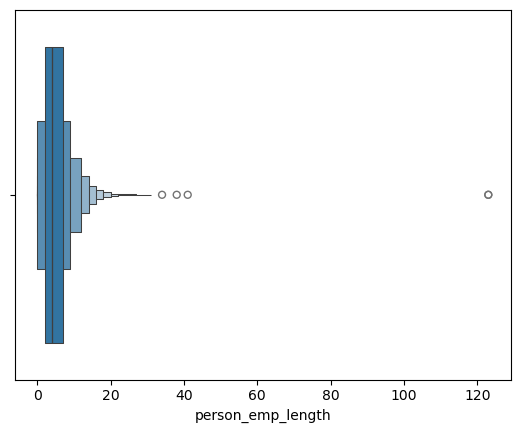

In [143]:
# Visualizar outliers
sns.boxplot(x=df['person_age'])
plt.show()

sns.boxenplot(x=df['person_emp_length'])
plt.show()

### Etapa 4.2 - Tratamento de outliers

In [144]:
# Removendo outliers, person_age acimas de 100 anos e person_emp_length acima de 80 anos
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 80]

In [145]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32574.000000,3.257400e+04,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000
mean,27.718426,6.587848e+04,4.782273,9588.018051,11.011544,0.218180,0.170202,5.804108
std,6.204987,5.253194e+04,3.979129,6320.249598,3.081657,0.413017,0.106755,4.053873
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,11.011695,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Valores acima de 100 anos para idade e 80 anos para anos trabalhados foram removidos por serem inconsistentes com a realidade, enquanto outros outliers plausíveis foram mantidos.

## Etapa 5 - Análise da vairável alvo

In [146]:
# Verificar o balanceamento do atributo alvo
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.78182
1    0.21818
Name: proportion, dtype: float64

- 0 → 78.18%
- 1 → 21.82%

Dataset desbalanceado (leve):
  - Não é crítico (exemplo 95/5).
  - Mas também não é perfeitamente balanceado.

Métricas mais importantes:
- precision
- recall
- F1-score
- ROC-AUC

## Etapa 6 - Análise das variáveis

In [147]:
# 1 - Separando as variáveis numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='str')


In [148]:
# 2 - Coerração com target
df[num_cols].corr()['loan_status'].sort_values(ascending=False)

loan_status                   1.000000
loan_percent_income           0.379250
loan_int_rate                 0.319302
loan_amnt                     0.105240
cb_person_cred_hist_length   -0.015472
person_age                   -0.020687
person_emp_length            -0.084378
person_income                -0.168485
Name: loan_status, dtype: float64

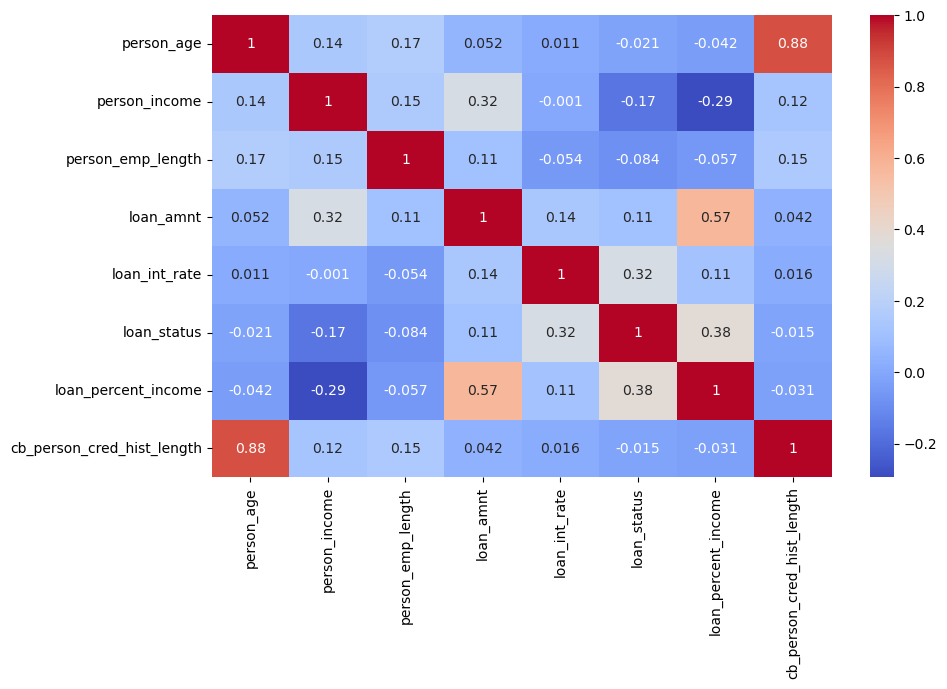

In [149]:
# 3 - Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

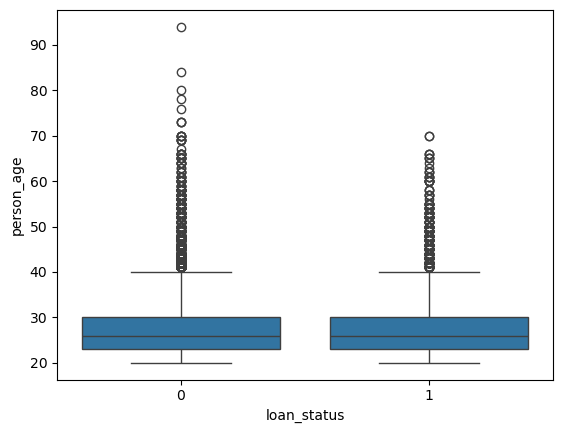

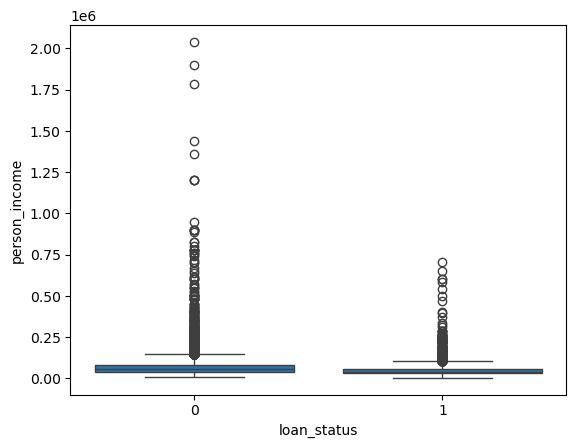

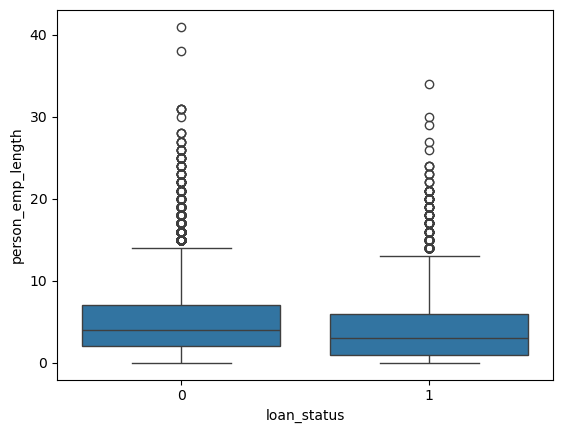

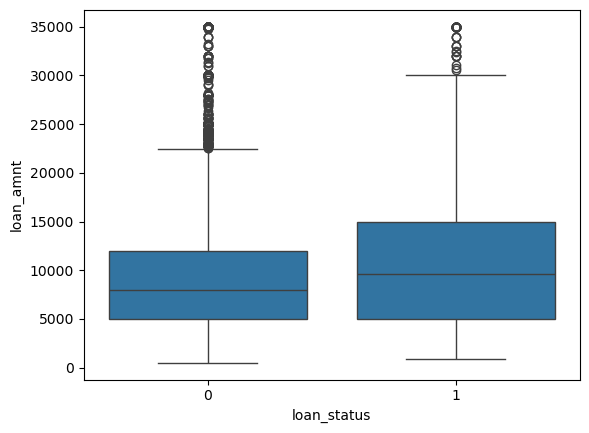

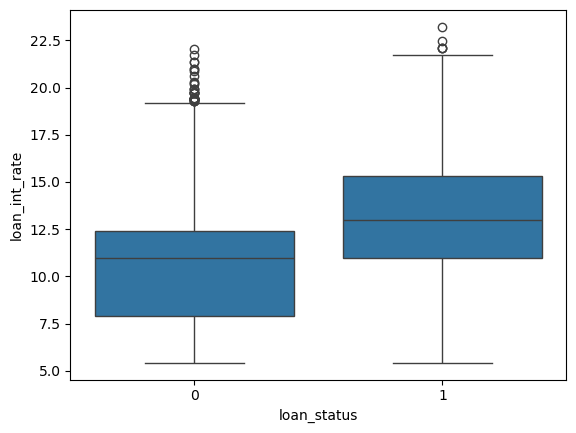

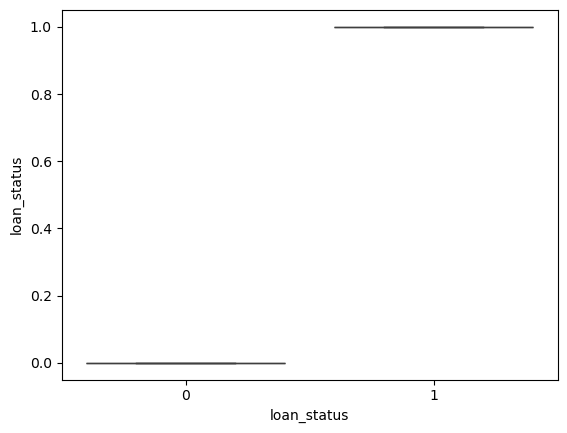

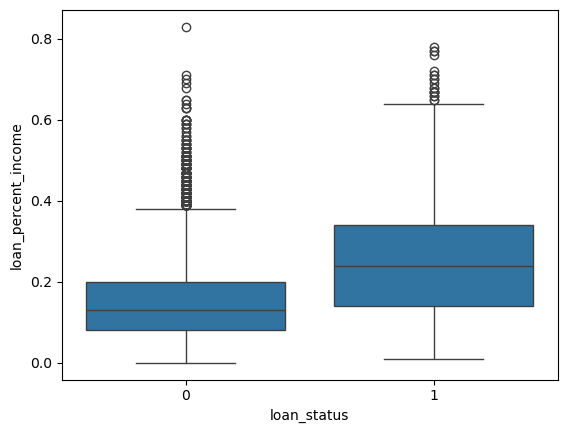

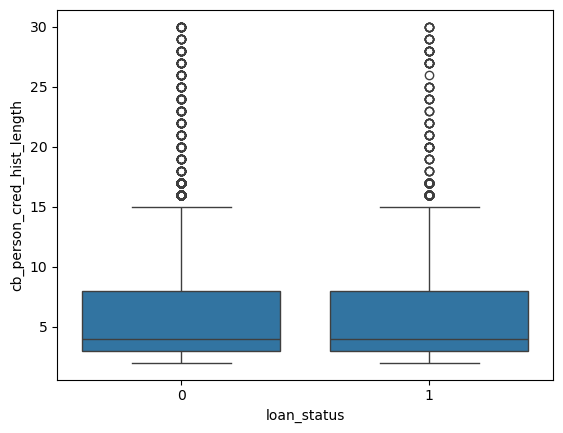

In [150]:
# 4 - Análise mais profunda
for i in num_cols:
    sns.boxplot(x='loan_status', y=i, data=df)
    plt.show()

## Etapa 7 - Variáveis categóricas

In [151]:
# 1 - Lista das colunas string
cat_cols = df.select_dtypes(include=['object', 'str']).columns
print(cat_cols)

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')


In [152]:
# 2 - Crosstab
for col in cat_cols:
    print(f'\n{col}')
    display(pd.crosstab(df[col], df['loan_status'], normalize='index'))


person_home_ownership


loan_status,0,1
person_home_ownership,,
MORTGAGE,0.874265,0.125735
OTHER,0.691589,0.308411
OWN,0.925310,0.074690
RENT,0.684284,0.315716



loan_intent


loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,0.714121,0.285879
EDUCATION,0.827779,0.172221
HOMEIMPROVEMENT,0.738974,0.261026
MEDICAL,0.732993,0.267007
PERSONAL,0.801232,0.198768
VENTURE,0.851819,0.148181



loan_grade


loan_status,0,1
loan_grade,,
A,0.900427,0.099573
B,0.837194,0.162806
C,0.792596,0.207404
D,0.409655,0.590345
E,0.355809,0.644191
F,0.294606,0.705394
G,0.015625,0.984375



cb_person_default_on_file


loan_status,0,1
cb_person_default_on_file,,
N,0.816027,0.183973
Y,0.622040,0.377960


`person_home_ownership` -> Clientes que alugam ou têm status não convencional apresentam maior risco de inadimplência.

`loan_intent` -> Finalidades como consolidação de dívida e despesas médicas apresentam maior risco.

`loan_grade` -> A variável loan_grade apresenta forte poder preditivo, com aumento progressivo da inadimplência conforme o risco.

`cb_person_default_on_file` -> Histórico negatino possuí maior chance de inadimplência

## Etapa 8 - Conlusão

Principais variávei relevantes.

Muito fortes:
- loan_grade
- loan_percent_income
- loan_int_rate
- cb_person_default_on_file 

Moderadas:
- person_home_ownership
- loan_intent

Fracas (isoladamente):
- person_age
- person_income
- person_emp_length

## Etapa 9 - Final (Criando o dataset tratado)

In [153]:
df.to_csv("../data/processed/dados_tratados.csv", index=False)

Checklist:
- carregar dados
- analisar estrutura
- tratar nulos
- tratar outliers absurdos
- analisar target
- correlação
- análise categórica